In [2]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
import sys
import os
# import plotly.express as px
# import plotly.graph_objects as go
#import squarify
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path
from src.utils import visualization_utils

In [4]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_species_vertebrates.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef90_D6NXI8,11676,ADF86160.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species
1,UniRef90_L0BZL1,11676,AFZ96186.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species
2,UniRef90_D6NXI9,11676,ADF86161.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species
3,UniRef90_A0A023HQ48,28875,AGO66969.1,['Homo sapiens'],Homo sapiens,Rotavirus A,species,9606,species
4,UniRef90_L0BZL4,11676,AFZ95585.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species
...,...,...,...,...,...,...,...,...,...
267860,UniRef90_A0A158WY96,1803956,AJS09554.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species
267861,UniRef90_A0A158WYC0,1803956,AJS09545.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species
267862,UniRef90_A0A158WZ44,1803956,AJS09547.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species
267863,UniRef90_A0A158WZ60,1803956,AJS09567.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species


In [5]:
n = df.shape[0]
n

267865

In [8]:
def get_label(pct, threshold):
    if pct <= threshold:
        return ""
    else:
        return f"{pct:.2f}%"

In [9]:
def get_data_for_pie_chart(df, col_name, n, threshold):
    count_data = df[col_name].value_counts().to_dict()

    label_data = {}
    prevalence_data = {}
    for k, v in count_data.items():
        prevalence = v/n*100
        prevalence_data[k] = f"{k} ({prevalence:.2f}%)"
        if prevalence <= threshold:
            prevalence_data[k] = f"{k} ({prevalence:.3f}%)"
            label_data[k] = ""
        else:
            label_data[k] = k
    return count_data, label_data, prevalence_data

## Virus Composition

In [12]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_name", n=n, threshold=.01)
others_hosts = []
for k,v in count_data.items():
    if (v/n*100) <= 0.011:
        others_hosts.append(k)
        
df["virus_name_mod"] = df["virus_name"].apply(lambda x: x if x not in others_hosts else f"Others ({len(others_hosts)} hosts)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_name"].isin(others_hosts)], col_name="virus_name_mod", n=n, threshold=0.01)

In [13]:
prevalence_data

{'Human immunodeficiency virus 1': 'Human immunodeficiency virus 1 (80.42%)',
 'Hepacivirus hominis': 'Hepacivirus hominis (4.09%)',
 'Hepatitis B virus': 'Hepatitis B virus (3.79%)',
 'Human immunodeficiency virus': 'Human immunodeficiency virus (0.78%)',
 'Human papillomavirus': 'Human papillomavirus (0.40%)',
 'Simian-Human immunodeficiency virus': 'Simian-Human immunodeficiency virus (0.38%)',
 'Human immunodeficiency virus 2': 'Human immunodeficiency virus 2 (0.29%)',
 'Rotavirus A': 'Rotavirus A (0.28%)',
 'Riboviria sp.': 'Riboviria sp. (0.21%)',
 'Simian immunodeficiency virus': 'Simian immunodeficiency virus (0.20%)',
 'Marmot picobirnavirus': 'Marmot picobirnavirus (0.20%)',
 'Paslahepevirus balayani': 'Paslahepevirus balayani (0.16%)',
 'Bacteriophage sp.': 'Bacteriophage sp. (0.15%)',
 'Hepatitis delta virus': 'Hepatitis delta virus (0.15%)',
 'Carp edema virus': 'Carp edema virus (0.15%)',
 'Torque teno virus': 'Torque teno virus (0.14%)',
 'Human betaherpesvirus 6': 'Huma

#### Virus Host Composition

In [34]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_host_name", n=n, threshold=.001)
others_hosts = []
for k,v in count_data.items():
    if (v/n*100) <= 0.1:
        others_hosts.append(k)
        
df["virus_host_name_mod"] = df["virus_host_name"].apply(lambda x: x if x not in others_hosts else f"Others ({len(others_hosts)} hosts)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_host_name"].isin(others_hosts)], col_name="virus_host_name_mod", n=n, threshold=0.001)

In [35]:
prevalence_data

{'Homo sapiens': 'Homo sapiens (92.37%)',
 'Sus scrofa': 'Sus scrofa (0.48%)',
 'Macaca mulatta': 'Macaca mulatta (0.40%)',
 'Hydrochoerus hydrochaeris': 'Hydrochoerus hydrochaeris (0.23%)',
 'Marmota himalayana': 'Marmota himalayana (0.20%)',
 'Gallus gallus': 'Gallus gallus (0.18%)',
 'Felis catus': 'Felis catus (0.16%)',
 'Cyprinus carpio': 'Cyprinus carpio (0.15%)',
 'Petroica australis': 'Petroica australis (0.15%)',
 'Gopherus morafkai': 'Gopherus morafkai (0.11%)',
 'Peromyscus boylii': 'Peromyscus boylii (0.11%)',
 'Marmota flaviventris': 'Marmota flaviventris (0.10%)'}

In [42]:
n_others = df[df['virus_host_name'].isin(others_hosts)].shape[0]
prevalence_data["Hosts with prevalence <= 0.1%"] = f"Hosts with prevalence <= 0.1%\n{len(others_hosts)} hosts ({n_others/n*100:.2f}%)"

In [43]:
prevalence_data

{'Homo sapiens': 'Homo sapiens (92.37%)',
 'Sus scrofa': 'Sus scrofa (0.48%)',
 'Macaca mulatta': 'Macaca mulatta (0.40%)',
 'Hydrochoerus hydrochaeris': 'Hydrochoerus hydrochaeris (0.23%)',
 'Marmota himalayana': 'Marmota himalayana (0.20%)',
 'Gallus gallus': 'Gallus gallus (0.18%)',
 'Felis catus': 'Felis catus (0.16%)',
 'Cyprinus carpio': 'Cyprinus carpio (0.15%)',
 'Petroica australis': 'Petroica australis (0.15%)',
 'Gopherus morafkai': 'Gopherus morafkai (0.11%)',
 'Peromyscus boylii': 'Peromyscus boylii (0.11%)',
 'Marmota flaviventris': 'Marmota flaviventris (0.10%)',
 'Hosts with prevalence <= 0.1%': 'Hosts with prevalence <= 0.1%\n1302 hosts (5.35%)'}

In [44]:
count_data

{'Homo sapiens': 247415,
 'Sus scrofa': 1286,
 'Macaca mulatta': 1081,
 'Hydrochoerus hydrochaeris': 627,
 'Marmota himalayana': 539,
 'Gallus gallus': 484,
 'Felis catus': 441,
 'Cyprinus carpio': 411,
 'Petroica australis': 408,
 'Gopherus morafkai': 292,
 'Peromyscus boylii': 282,
 'Marmota flaviventris': 271}

In [45]:
count_data["Hosts with prevalence <= 0.1%"] = n_others

In [46]:
count_data.pop("Homo sapiens")

247415

In [47]:
count_data

{'Sus scrofa': 1286,
 'Macaca mulatta': 1081,
 'Hydrochoerus hydrochaeris': 627,
 'Marmota himalayana': 539,
 'Gallus gallus': 484,
 'Felis catus': 441,
 'Cyprinus carpio': 411,
 'Petroica australis': 408,
 'Gopherus morafkai': 292,
 'Peromyscus boylii': 282,
 'Marmota flaviventris': 271,
 'Hosts with prevalence <= 0.1%': 14328}

20450


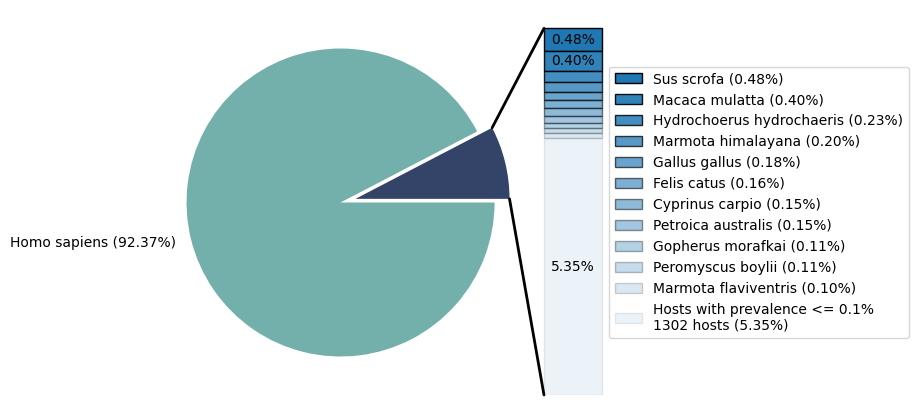

In [54]:
from matplotlib.patches import ConnectionPatch

# make figure and assign axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
fig.subplots_adjust(wspace=-.5)

# pie chart parameters
pie_values = [df[df['virus_host_name'] != "Homo sapiens"].shape[0], df[df['virus_host_name'] == "Homo sapiens"].shape[0]]
pie_labels = ['', prevalence_data["Homo sapiens"]]
explode = [0.1, 0]

# rotate so that first wedge is split by the x-axis
#angle = -180 * overall_ratios[0]
wedges, *_ = ax1.pie(pie_values, startangle=0,
                     labels=pie_labels, explode=explode, colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(pie_labels)+1, reverse=True))

# bar chart parameters
bar_values = [i for i in reversed(count_data.values())]
bar_labels = [i for i in reversed(count_data.keys())]
bottom = 1
width = 10.1
bar_total = sum(bar_values)

print(bar_total)
# Adding from the top matches the legend.
for j, (val, label) in enumerate(reversed([*zip(bar_values, bar_labels)])):
    height = val / bar_total
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='C0', label=prevalence_data[label], edgecolor="black",
                 alpha=1-(1/len(bar_labels) * j))
    label_pct = val/n*100
    if label_pct > .4:
        ax2.bar_label(bc, labels=[f"{val/n*100:.2f}%"], label_type='center')

ax2.legend(loc="center",
          bbox_to_anchor=(.9, .5))
ax2.axis('off')
ax2.set_xlim(-4*width, 4*width)

# use ConnectionPatch to draw lines between the two plots
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r
bar_height = 1

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(2)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(2)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "..", "output/visualization/haven/vertebrates_hosts_pie_bar.pdf"), bbox_inches="tight", dpi=600)
plt.show()

### Non-IV Dataset

In [7]:
df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv.csv"))
n = df.shape[0]
df

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,seq,seq_len
0,UniRef90_A0A023HQ48,28875,AGO66969.1,['Homo sapiens'],Homo sapiens,Rotavirus A,species,9606,species,KGWPTGSVYFKEYSSIVDFSVDPQLYCDYNLVLMKYDQNLELDMSE...,218
1,UniRef90_A0A291S408,147712,ATL74331.1,['Homo sapiens'],Homo sapiens,Rhinovirus B,species,9606,species,ATLPTVPSDNVETRTTYMHYDGTETSLESFLGRAACVHVTTIENKL...,110
2,UniRef90_Q8B3A4,3052493,CAD44491.1,['Clethrionomys glareolus'],Clethrionomys glareolus,Orthohantavirus puumalaense,species,447135,species,VEFLKRNKVYFMNRQDVLDKNHVADIDKLIDYAASGDPTSPEDIES...,87
3,UniRef90_Q8B3J5,37741,CAD20665.1,['Rattus rattus'],Rattus rattus,Hantavirus sp.,species,10117,species,EPTGQTADWLTIIIYLTSFVIPIILKALYMLTTRGRQTTKDNKGMR...,194
4,UniRef90_A0A7M1VN82,2732655,QOS14274.1,['Homo sapiens; male'],Homo sapiens,Vientovirus,species,9606,species,MSLHLDCVNLLLTYNDPVRKDLWGYEPLRPTNYLRISKSMNNIRRC...,348
...,...,...,...,...,...,...,...,...,...,...,...
47787,UniRef90_A0A158WY96,1803956,AJS09554.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,NSSSPNKVHCIVQGRLGDDAKFFCPTGSLVSFQNSWGSQMDLTDPL...,194
47788,UniRef90_A0A158WYC0,1803956,AJS09545.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,LTSAQDEGPLGGEKPNYFLNFRAINVDIFTVSHTKVDNIFGRAWFS...,116
47789,UniRef90_A0A158WZ44,1803956,AJS09547.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,SSSPSSVHCIVQGRLGDDAKFFCPAGSIVTFQNSWGSQMDLTDPLC...,196
47790,UniRef90_A0A158WZ60,1803956,AJS09567.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,NGNLWRSQLTFPKQGHGMLSQFFAYFTGELNIHILYMASSGFLRVA...,207


#### Virus Composition

In [8]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_name", n=n, threshold=.01)
others_viruses = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_viruses.append(k)
        
df["virus_name_mod"] = df["virus_name"].apply(lambda x: x if x not in others_viruses else f"Others ({len(others_viruses)} viruses)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_name"].isin(others_viruses)], col_name="virus_name_mod", n=n, threshold=0.01)

In [9]:
prevalence_data

{'Hepacivirus hominis': 'Hepacivirus hominis (22.91%)',
 'Hepatitis B virus': 'Hepatitis B virus (21.24%)',
 'Human papillomavirus': 'Human papillomavirus (2.26%)',
 'Rotavirus A': 'Rotavirus A (1.57%)',
 'Riboviria sp.': 'Riboviria sp. (1.18%)',
 'Marmot picobirnavirus': 'Marmot picobirnavirus (1.11%)'}

In [10]:
n_others = df[df['virus_name'].isin(others_viruses)].shape[0]
prevalence_data["Viruses with prevalence <= 1%"] = f"Viruses with prevalence <= 1%\n{len(others_viruses)} viruses ({n_others/n*100:.2f}%)"
prevalence_data

{'Hepacivirus hominis': 'Hepacivirus hominis (22.91%)',
 'Hepatitis B virus': 'Hepatitis B virus (21.24%)',
 'Human papillomavirus': 'Human papillomavirus (2.26%)',
 'Rotavirus A': 'Rotavirus A (1.57%)',
 'Riboviria sp.': 'Riboviria sp. (1.18%)',
 'Marmot picobirnavirus': 'Marmot picobirnavirus (1.11%)',
 'Viruses with prevalence <= 1%': 'Viruses with prevalence <= 1%\n3766 viruses (49.74%)'}

In [11]:
count_data

{'Hepacivirus hominis': 10947,
 'Hepatitis B virus': 10152,
 'Human papillomavirus': 1078,
 'Rotavirus A': 749,
 'Riboviria sp.': 563,
 'Marmot picobirnavirus': 529}

In [12]:
count_data["Viruses with prevalence <= 1%"] = n_others
count_data

{'Hepacivirus hominis': 10947,
 'Hepatitis B virus': 10152,
 'Human papillomavirus': 1078,
 'Rotavirus A': 749,
 'Riboviria sp.': 563,
 'Marmot picobirnavirus': 529,
 'Viruses with prevalence <= 1%': 23774}

In [13]:
count_data.pop("Hepacivirus hominis")

10947

In [14]:
count_data.pop("Hepatitis B virus")

10152

In [31]:
df["virus_name"].nunique()

3772

26693


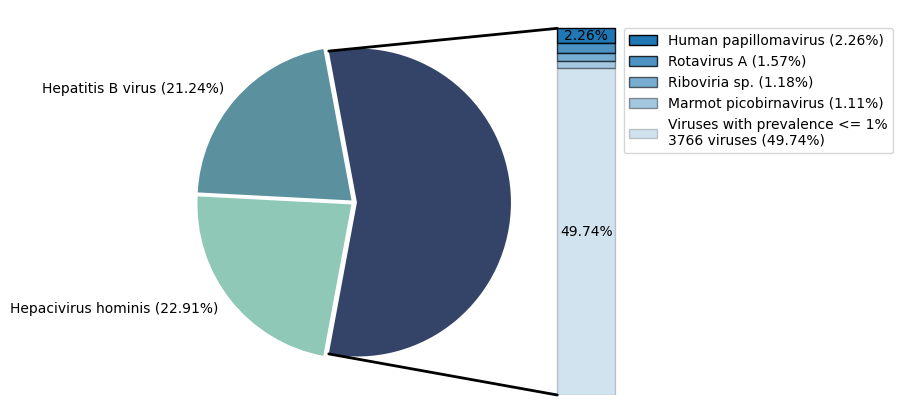

In [30]:
from matplotlib.patches import ConnectionPatch

selected_viruses = ["Hepacivirus hominis", "Hepatitis B virus"]

# make figure and assign axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
fig.subplots_adjust(wspace=-.5)

# pie chart parameters
pie_values = [df[~df['virus_name'].isin(selected_viruses)].shape[0],
              df[df['virus_name'] == "Hepatitis B virus"].shape[0], 
              df[df['virus_name'] == "Hepacivirus hominis"].shape[0]]
pie_labels = ['', prevalence_data["Hepatitis B virus"], prevalence_data["Hepacivirus hominis"]]
explode = [0.02, 0.02, 0.02]

# rotate so that first wedge is split by the x-axis
#angle = -180 * overall_ratios[0]
wedges, *_ = ax1.pie(pie_values, startangle=-180 * pie_values[0]/n, #wedgeprops={"linewidth": 1, "edgecolor": "white"},
                     labels=pie_labels, explode=explode, colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(pie_labels)+1, reverse=True))

# bar chart parameters
bar_values = [i for i in reversed(count_data.values())]
bar_labels = [i for i in reversed(count_data.keys())]
bottom = 1
width = 10.1
bar_total = sum(bar_values)

print(bar_total)
# Adding from the top matches the legend.
for j, (val, label) in enumerate(reversed([*zip(bar_values, bar_labels)])):
    height = val / bar_total
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='C0', label=prevalence_data[label], edgecolor="black", 
                 alpha=1-(1/len(bar_labels) * j))
    label_pct = val/n*100
    if label_pct > 2:
        ax2.bar_label(bc, labels=[f"{val/n*100:.2f}%"], label_type='center')

ax2.legend(loc="center",
          bbox_to_anchor=(.87, .79))
ax2.axis('off')
ax2.set_xlim(-4*width, 4*width)

# use ConnectionPatch to draw lines between the two plots
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r
bar_height = 1

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(2)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(2)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/noniv_viruses_pie_bar.pdf"), bbox_inches="tight", dpi=600)
plt.show()

#### Virus Host Composition

In [5]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_host_name", n=n, threshold=1)
others_hosts = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_hosts.append(k)
        
df["virus_host_name_mod"] = df["virus_host_name"].apply(lambda x: x if x not in others_hosts else f"Rare ({len(others_hosts)} hosts)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_host_name"].isin(others_hosts)], col_name="virus_host_name_mod", n=n, threshold=0.01)
prevalence_data

{'Homo sapiens': 'Homo sapiens (60.22%)',
 'Sus scrofa': 'Sus scrofa (2.69%)',
 'Hydrochoerus hydrochaeris': 'Hydrochoerus hydrochaeris (1.31%)',
 'Marmota himalayana': 'Marmota himalayana (1.13%)',
 'Gallus gallus': 'Gallus gallus (1.01%)'}

In [6]:
n_others = df[df['virus_host_name'].isin(others_hosts)].shape[0]
prevalence_data["Hosts with prevalence <= 1%"] = f"Hosts with prevalence <= 1% (Rare hosts)\n({n_others/n*100:.2f}%)"
prevalence_data

{'Homo sapiens': 'Homo sapiens (60.22%)',
 'Sus scrofa': 'Sus scrofa (2.69%)',
 'Hydrochoerus hydrochaeris': 'Hydrochoerus hydrochaeris (1.31%)',
 'Marmota himalayana': 'Marmota himalayana (1.13%)',
 'Gallus gallus': 'Gallus gallus (1.01%)',
 'Hosts with prevalence <= 1%': 'Hosts with prevalence <= 1% (Rare hosts)\n(33.63%)'}

In [7]:
count_data

{'Homo sapiens': 28782,
 'Sus scrofa': 1286,
 'Hydrochoerus hydrochaeris': 627,
 'Marmota himalayana': 539,
 'Gallus gallus': 484}

In [8]:
count_data["Hosts with prevalence <= 1%"] = n_others
count_data

{'Homo sapiens': 28782,
 'Sus scrofa': 1286,
 'Hydrochoerus hydrochaeris': 627,
 'Marmota himalayana': 539,
 'Gallus gallus': 484,
 'Hosts with prevalence <= 1%': 16074}

60.22346615791321
2.690826915204525
1.311935018748045
1.1278037913143635
1.0127217508852482
33.633244037628174


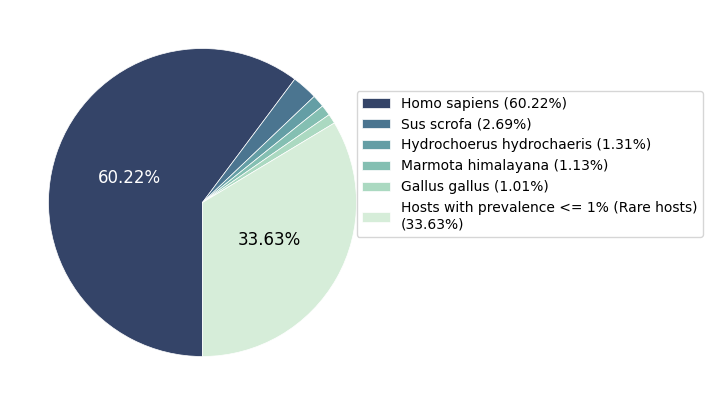

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

def get_label(pct, threshold):
    print(pct)
    if pct <= threshold:
        return ""
    else:
        return f"{pct:.2f}%"

threshold=1.0
wedges, texts, autotexts = ax.pie(count_data.values(), autopct=lambda pct: get_label(pct, threshold=3), 
                                  pctdistance=.5, labeldistance=.7, counterclock=False, startangle=-90,
                                  colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(count_data), reverse=True), 
                                  wedgeprops={"linewidth": .5, "edgecolor": "white"})

ax.legend(wedges, prevalence_data.values(),
          title="",
          loc="center",
          bbox_to_anchor=(1.35, .6), ncol=1)
plt.setp(autotexts, size=12, color="black")
plt.setp(autotexts[0], size=12, color="white")
plt.setp(autotexts[-1], size=12, color="black")
#ax.set_title("IV Dataset", fontsize=14, y=0, pad=0)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/noniv_hosts_pie.pdf"), bbox_inches="tight", dpi=600)
plt.show()

## Sequence Length Distribution

In [ ]:
def seq_length_analysis(input_file_path, output_file_path):
    df = pd.read_csv(input_file_path)
    df["seq_len"] = df["seq"].apply(lambda x: len(x))
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")

    plt.clf()
    sns.set_theme()
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df["seq_len"].values, bins=400, ax=ax, fill=True, alpha=1, kde=False, color=sns.color_palette("dark")[0])
    sns.rugplot(data=df, x="seq_len", height=-.03, clip_on=False, color="black", alpha=.5)
    ax.set_xlabel("Sequence Length", fontsize=12)
    ax.set_ylabel("Number of sequences", fontsize=12)
    ax.set_xticks(np.arange(0, df["seq_len"].max() + 1, 1000))
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_xlim((0, df["seq_len"].max() + 10))
    plt.savefig(output_file_path, bbox_inches="tight", dpi=600)
    plt.show()

### Pretraining Dataset

In [ ]:
seq_length_analysis(os.path.join(os.getcwd(), "..", "..", "..", "..", "input/data/uniref90/20240131/uniref90_viridae.csv"),
                    os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/pretrain_dataset_seqlength_dist.png"))

In [8]:
df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "..", "..", "..", "input/data/uniref90/20240131/uniref90_viridae_valid_embl_hosts_metadata_species_vertebrates_w_seq.csv"))
n = df.shape[0]
df

FileNotFoundError: [Errno 2] No such file or directory: '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/uniref90/../../../../../input/data/uniref90/20240131/uniref90_viridae_valid_embl_hosts_metadata_species_vertebrates_w_seq.csv'

### Finetuning Dataset

In [ ]:
seq_length_analysis(os.path.join(os.getcwd(), "..", "..", "..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv_t0.01_c5.csv"),
                    os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/finetune_dataset_seqlength_dist.png"))